In [1]:
from pixell import enmap, enplot
import yaml
import numpy as np
import astropy.units as u
%load_ext autoreload
%autoreload 2

In [2]:
maskfile_list = ["/global/cfs/cdirs/cmb/data/act_dr6/dr6.02/nilc/published/ilc_footprint_mask.fits",
"/global/cfs/cdirs/cmb/data/act_dr6/dr6.02/nilc/published/ilc_inpaint_mask.fits",
"/global/cfs/cdirs/cmb/data/act_dr6/dr6.02/nilc/published/ilc_subtracted_mask.fits"]


In [ ]:
if maskfile_list is not None:
        print("Found masks")
        if maskfile_list[0].endswith("shrunk.fits") and len(maskfile_list)==1:
            maskpath = maskfile_list[0]
        else:
            for i, maskpath in enumerate(maskfile_list):
                print(maskpath)
                try:
                    mask = enmap.read_map(maskpath)
                    if i == 0:
                        # make binary
                        mask[mask<1]=0
                        mask[mask!=0]=1
                        # enplot.pshow(mask, downgrade=20, colorbar=True, ticks=30, font_size=30)
                        combined_mask = mask
                    else:
                        # enplot.pshow(mask, downgrade=10, colorbar=True, ticks=10)
                        newmask = enmap.zeros(mask.shape, mask.wcs)
                        print(np.sum(newmask))
                        newmask[mask<0.01] = 1
                        # make sure newmask is binary
                        print(np.sum((newmask!=0) & (newmask!=1)))
                        enplot.pshow(newmask, downgrade=20, colorbar=True, ticks=30, font_size=30)
                        combined_mask *= newmask

                        
                except Exception as e:
                    raise ValueError(f"Could not read mask file {maskpath}. Please ensure it is enmap format.") from e
        enplot.pshow(combined_mask, downgrade=10, colorbar=True)

        # shrink the True part of the mask the amount given, or by size of the cutouts
        print("Shrinking mask...")
        combined_mask = enmap.shrink_mask(combined_mask, (0.1*u.deg).to(u.rad).value)
        

In [ ]:
enplot.pshow(combined_mask, downgrade=10, colorbar=True, ticks=20, font_size=20)

In [ ]:
# write mask to new file and delete
maskpath = "/pscratch/sd/m/mlokken/actxdesi/act_data/combined_mask_sources_shrunkp1deg.fits"
# # Ensure FITS-compatible binary mask
combined_mask = (combined_mask > 0).astype(np.uint8)
enmap.write_map(maskpath, combined_mask) # error here ML
print("Combined mask written to", maskpath)


## Testing from here on

In [5]:
maskpath = "/pscratch/sd/m/mlokken/actxdesi/act_data/combined_mask_sources_shrunkp1deg.fits"

In [6]:
# read in the mask
combined_mask_read = enmap.read_map(maskpath)
# enplot.pshow(combined_mask_read, downgrade=10, colorbar=True, ticks=20, font_size=20)

In [7]:
import catalog

In [8]:
cat = catalog.Catalog(
    pathInCatalog="/pscratch/sd/m/mlokken/actxdesi/desidr2lrg_analysis/lrg_cigale_masked_0pt50_0pt60_8pt0Mpc_asym_xy.csv",
)

- read input catalog from /pscratch/sd/m/mlokken/actxdesi/desidr2lrg_analysis/lrg_cigale_masked_0pt50_0pt60_8pt0Mpc_asym_xy.csv


In [9]:
cat.mask_catalog(combined_mask_read)

In [10]:
import matplotlib.pyplot as plt

In [11]:
combined_mask_read_dg = enmap.downgrade(combined_mask_read, 10)

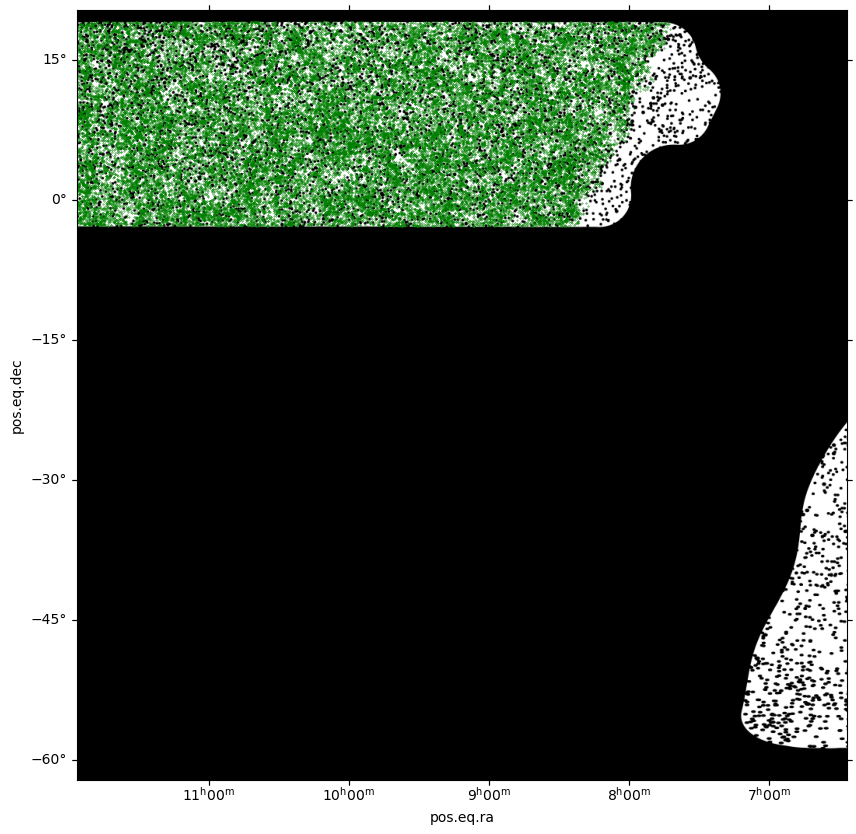

In [30]:
# plot the new points over the mask
plt.figure(figsize=(10, 10))
pix = enmap.sky2pix(
    combined_mask_read.shape,
    combined_mask_read.wcs,
    np.deg2rad([cat.dec, cat.ra])
)
y, x = pix

# Overlay points
ax = plt.subplot(projection=combined_mask_read_dg.wcs)

ax.imshow(combined_mask_read_dg, origin="lower", cmap="gray", vmin=0, vmax=1)
ax.scatter(cat.ra, cat.dec, s=.1, color='green', transform=ax.get_transform("world"))
cutout_size = 10 #deg
ax.set_xlim([10,1000])
ax.set_ylim([10,1000])
plt.show()

# enplot.show()

In [ ]:
# do the same for a small chunk